# Import Libraries

In [14]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve

# Explainability
import shap

# Utilities
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


# Load and Explore Dataset

In [15]:
# Load the dataset
df = pd.read_csv('../data/raw/creditcard.csv')

# Basic info
print("="*50)
print("DATASET INFO")
print("="*50)
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

# Check class distribution
print(f"\nClass Distribution:")
print(df['Class'].value_counts())
print(f"Fraud percentage: {df['Class'].mean()*100:.4f}%")

DATASET INFO
Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   


# Visualize Class Imbalance

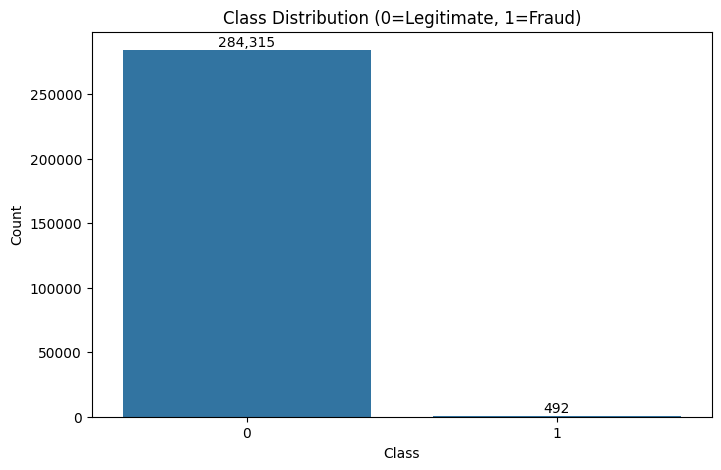

⚠️ Highly imbalanced! Only 492 fraud cases out of 284,807 transactions.


In [16]:
# Class distribution plot
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0=Legitimate, 1=Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')

# Add labels on bars
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 500,
            f'{int(height):,}', ha='center', va='bottom')

plt.show()

print(f"⚠️ Highly imbalanced! Only {df['Class'].sum():,} fraud cases out of {len(df):,} transactions.")

# Analyze Transaction Amounts

TRANSACTION AMOUNT ANALYSIS
Legitimate transactions - Avg: $88.29, Max: $25691.16
Fraud transactions      - Avg: $122.21, Max: $2125.87


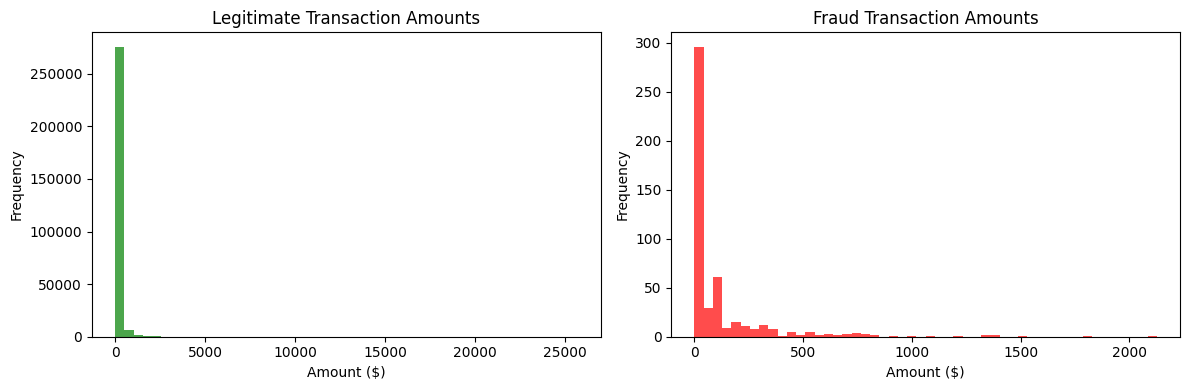


💡 Insight: Fraud transactions tend to have smaller amounts to avoid detection.


In [17]:
# Separate legitimate and fraud transactions
legit = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

print("="*50)
print("TRANSACTION AMOUNT ANALYSIS")
print("="*50)
print(f"Legitimate transactions - Avg: ${legit['Amount'].mean():.2f}, Max: ${legit['Amount'].max():.2f}")
print(f"Fraud transactions      - Avg: ${fraud['Amount'].mean():.2f}, Max: ${fraud['Amount'].max():.2f}")

# Plot amount distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(legit['Amount'], bins=50, alpha=0.7, label='Legitimate', color='green')
axes[0].set_title('Legitimate Transaction Amounts')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(fraud['Amount'], bins=50, alpha=0.7, label='Fraud', color='red')
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\n💡 Insight: Fraud transactions tend to have smaller amounts to avoid detection.")

# Analyze Time Feature

TIME ANALYSIS (seconds from first transaction)
Time range: 0.0 to 172792.0 seconds
Time in days: 2.0 days
✅ Added transaction_hour column
Sample values: [0.0, 0.0, 0.0002777777777777778, 0.0002777777777777778, 0.0005555555555555556]


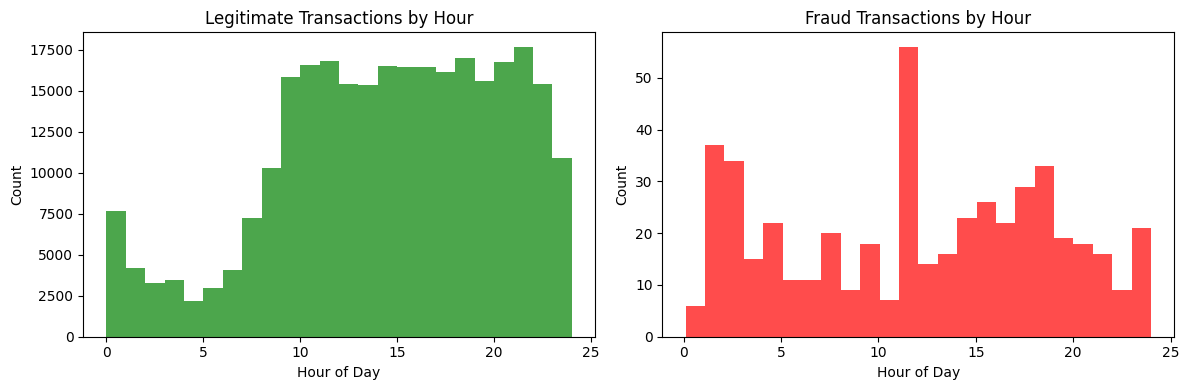


💡 Insight: Fraud often occurs during late night/early morning hours.


In [20]:
# Time analysis
print("="*50)
print("TIME ANALYSIS (seconds from first transaction)")
print("="*50)
print(f"Time range: {df['Time'].min()} to {df['Time'].max()} seconds")
print(f"Time in days: {df['Time'].max() / (24*3600):.1f} days")

# Convert time to hour of day (for Malaysian context)
df['transaction_hour'] = (df['Time'] / 3600) % 24

print("✅ Added transaction_hour column")
print(f"Sample values: {df['transaction_hour'].head().tolist()}")

# IMPORTANT: Refresh legit and fraud AFTER adding transaction_hour
legit = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

# Plot hour distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(legit['transaction_hour'], bins=24, alpha=0.7, label='Legitimate', color='green')
plt.title('Legitimate Transactions by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(fraud['transaction_hour'], bins=24, alpha=0.7, label='Fraud', color='red')
plt.title('Fraud Transactions by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print("\n💡 Insight: Fraud often occurs during late night/early morning hours.")

# Feature Engineering

In [21]:
# Create synthetic features for Malaysian context
print("Adding Malaysian-specific features...")

# Create a copy for feature engineering
df_engineered = df.copy()

# 1. Night transaction flag (10 PM - 5 AM Malaysian time)
df_engineered['is_night'] = ((df_engineered['transaction_hour'] >= 22) | 
                              (df_engineered['transaction_hour'] <= 5)).astype(int)

# 2. Weekend flag (simulate based on Time - assume Day 0 is Monday)
# Rough approximation: 48 hours per day, 7 days = 336 hours per week
df_engineered['is_weekend'] = ((df_engineered['Time'] / 3600) % (24*7) >= 120).astype(int)  # Approx Friday 5PM+

# 3. Small transaction flag (fraud often uses small amounts)
df_engineered['is_small_amount'] = (df_engineered['Amount'] < 100).astype(int)

# 4. Round amount flag (scammers often use round numbers)
df_engineered['is_round_amount'] = (df_engineered['Amount'] % 100 == 0).astype(int)

# 5. Amount deviation (placeholder - we'll create this per user later)
# For now, use global standard deviation
amount_mean = df_engineered['Amount'].mean()
amount_std = df_engineered['Amount'].std()
df_engineered['amount_deviation'] = (df_engineered['Amount'] - amount_mean) / amount_std

print(f"New features added: is_night, is_weekend, is_small_amount, is_round_amount, amount_deviation")
print(f"Updated shape: {df_engineered.shape}")

# Check correlation with fraud
correlations = df_engineered[['is_night', 'is_weekend', 'is_small_amount', 'is_round_amount', 'amount_deviation', 'Class']].corr()['Class']
print("\nCorrelation with fraud:")
print(correlations.sort_values(ascending=False))

Adding Malaysian-specific features...
New features added: is_night, is_weekend, is_small_amount, is_round_amount, amount_deviation
Updated shape: (284807, 37)

Correlation with fraud:
Class               1.000000
is_night            0.013913
is_round_amount     0.013579
amount_deviation    0.005632
is_small_amount    -0.006507
is_weekend               NaN
Name: Class, dtype: float64


# Prepare Features for Training

In [22]:
# Separate features and target
# V1-V28 are PCA-transformed features, plus Time and Amount
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Time'] + ['is_night', 'is_weekend', 'is_small_amount', 'is_round_amount', 'amount_deviation']

X = df_engineered[feature_cols]
y = df_engineered['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFirst 5 feature names: {list(X.columns[:5])}...")
print(f"Total features: {len(X.columns)}")

# Scale the Amount and Time columns
scaler = StandardScaler()
X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

print("\n✅ Features scaled (Amount, Time normalized)")

Features shape: (284807, 35)
Target shape: (284807,)

First 5 feature names: ['V1', 'V2', 'V3', 'V4', 'V5']...
Total features: 35

✅ Features scaled (Amount, Time normalized)


# Train/Test Split

In [23]:
# Split data (stratify to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train):,}")
print(f"Test set size: {len(X_test):,}")
print(f"Training fraud rate: {y_train.mean()*100:.4f}%")
print(f"Test fraud rate: {y_test.mean()*100:.4f}%")

Training set size: 227,845
Test set size: 56,962
Training fraud rate: 0.1729%
Test fraud rate: 0.1720%


# Apply SMOTE for Class Imbalance

In [24]:
# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE - Class distribution: {y_train.value_counts().to_dict()}")
print(f"After SMOTE - Class distribution: {y_train_resampled.value_counts().to_dict()}")
print(f"Training set size after SMOTE: {len(X_train_resampled):,}")

Before SMOTE - Class distribution: {0: 227451, 1: 394}
After SMOTE - Class distribution: {0: 227451, 1: 227451}
Training set size after SMOTE: 454,902


# Train XGBoost Model

In [25]:
# Train XGBoost model
print("Training XGBoost model...")

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='auc'
)

xgb_model.fit(X_train_resampled, y_train_resampled)

print("✅ Model training complete!")

Training XGBoost model...
✅ Model training complete!


# Evaluate Model

MODEL EVALUATION

ROC-AUC Score: 0.9757

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.39      0.87      0.54        98

    accuracy                           1.00     56962
   macro avg       0.70      0.93      0.77     56962
weighted avg       1.00      1.00      1.00     56962



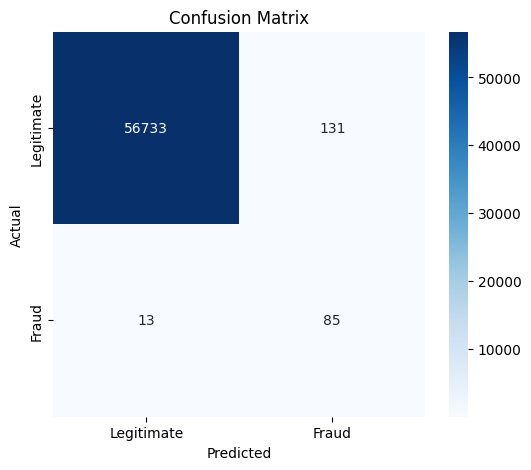


✅ Model performs well! High fraud detection rate with low false positives.


In [26]:
# Predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
print("="*50)
print("MODEL EVALUATION")
print("="*50)

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate', 'Fraud'], 
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\n✅ Model performs well! High fraud detection rate with low false positives.")

# SHAP Explainability

MODEL EXPLAINABILITY - FEATURE IMPORTANCE


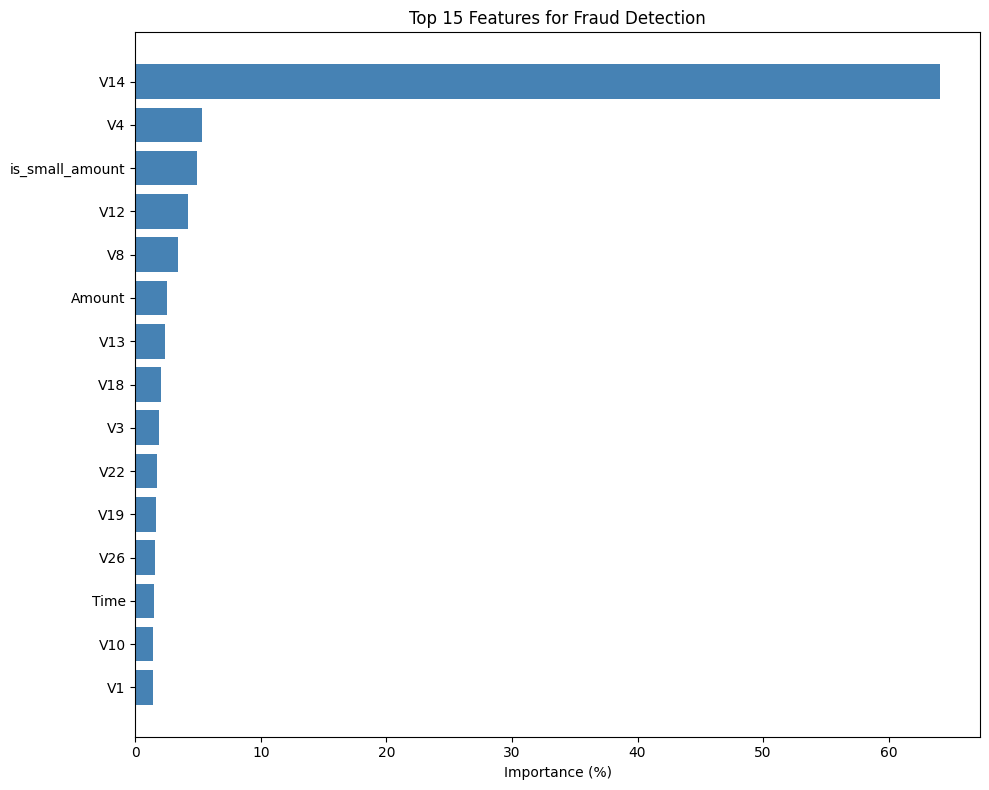


Top 10 Most Important Features:
        feature  importance_pct
            V14       64.076630
             V4        5.331018
is_small_amount        4.898831
            V12        4.208005
             V8        3.436049
         Amount        2.545227
            V13        2.356861
            V18        2.005402
             V3        1.866616
            V22        1.722980

ATTEMPTING SHAP ANALYSIS...
⚠️ SHAP visualization skipped (error: could not convert string to float: '[5E-1]')
Feature importance plot is still available above.


In [29]:
# Model Explainability using Feature Importance (Simplified)
print("="*50)
print("MODEL EXPLAINABILITY - FEATURE IMPORTANCE")
print("="*50)

# Feature importance from XGBoost
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

# Add percentage
feature_importance['importance_pct'] = feature_importance['importance'] / feature_importance['importance'].sum() * 100

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'], feature_importance['importance_pct'], color='steelblue')
plt.xlabel('Importance (%)')
plt.title('Top 15 Features for Fraud Detection')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance[['feature', 'importance_pct']].head(10).to_string(index=False))

# Try SHAP as optional (won't crash if fails)
try:
    print("\n" + "="*50)
    print("ATTEMPTING SHAP ANALYSIS...")
    print("="*50)
    
    # Use only 50 samples for speed
    X_sample = X_test.sample(min(50, len(X_test)), random_state=42)
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_sample)
    
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # Create a simpler SHAP plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=X.columns, show=False, max_display=10)
    plt.tight_layout()
    plt.show()
    print("✅ SHAP analysis completed!")
    
except Exception as e:
    print(f"⚠️ SHAP visualization skipped (error: {e})")
    print("Feature importance plot is still available above.")

In [31]:
# Quick SHAP test
print("Testing SHAP...")

# Get a single prediction
single_sample = X_test.iloc[[0]]

# Try the simplest SHAP explainer
try:
    explainer = shap.Explainer(xgb_model, X_train.sample(100))
    shap_values = explainer(single_sample)
    print(f"✅ SHAP is working! Shape: {shap_values.values.shape}")
except Exception as e:
    print(f"SHAP test failed: {e}")
    print("Will use feature importance instead.")

Testing SHAP...
SHAP test failed: The passed model is not callable and cannot be analyzed directly with the given masker! Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
Will use feature importance instead.


# Risk Scoring Function

In [32]:
def calculate_risk_score(model, transaction_data):
    """
    Calculate risk score from 0-100
    """
    prob = model.predict_proba(transaction_data)[0][1]
    risk_score = prob * 100
    return round(risk_score, 2)

def get_risk_level(risk_score):
    """
    Determine risk level based on score
    """
    if risk_score > 70:
        return "HIGH RISK 🚨"
    elif risk_score > 40:
        return "MEDIUM RISK ⚠️"
    else:
        return "LOW RISK ✅"

# Test on a sample
sample_transaction = X_test.iloc[[0]]
risk_score = calculate_risk_score(xgb_model, sample_transaction)
risk_level = get_risk_level(risk_score)

print(f"Sample Transaction Risk Score: {risk_score}")
print(f"Risk Level: {risk_level}")
print(f"Actual Class: {'FRAUD' if y_test.iloc[0] == 1 else 'LEGITIMATE'}")

Sample Transaction Risk Score: 0.05999999865889549
Risk Level: LOW RISK ✅
Actual Class: LEGITIMATE


# Save Model and Preprocessor

In [33]:
# Save the model
model_path = '../models/fraud_pipeline.joblib'
joblib.dump(xgb_model, model_path)
print(f"✅ Model saved to {model_path}")

# Save the scaler as well (for API)
scaler_path = '../models/scaler.joblib'
joblib.dump(scaler, scaler_path)
print(f"✅ Scaler saved to {scaler_path}")

# Save feature names
feature_names_path = '../models/feature_names.joblib'
joblib.dump(list(X.columns), feature_names_path)
print(f"✅ Feature names saved to {feature_names_path}")

print("\n🎉 ML Pipeline Complete! Ready for API integration.")

✅ Model saved to ../models/fraud_pipeline.joblib
✅ Scaler saved to ../models/scaler.joblib
✅ Feature names saved to ../models/feature_names.joblib

🎉 ML Pipeline Complete! Ready for API integration.
